## Phân tích tin tuyển dụng ngành CNTT
### - Làm sạch dữ liệu, đặt các stopword đơn giản.
### - Tạo WordCloud
### - Xây dựng đồ thị từ khóa có liên kết với nhau
### - Xây dựng biểu đồ top các từ khóa ngành nghề xuất hiện

**Tải các thư viện cần thiết**

In [ ]:
pip install -r requirements.txt

In [19]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import networkx as nx

**Đọc dữ liệu**

In [20]:
with open("output.json", "r", encoding="utf-8") as f:
    data = json.load(f)

jobs = pd.DataFrame(data["listJob"])

**Làm sạch tên job**

In [21]:
jobs['job_title'] = jobs['name'].fillna('').str.replace(r'\s+', ' ', regex=True).str.strip()

**Stopwords cơ bản (tiếng Việt + Anh)**

In [22]:
stopwords = set([
    "các","và","là","những","của","trong","cho","khi","được",
    "the","a","an","and","or","is","to","with","on","at","in",
    "by","for","from","this","that","it","as","are"
])

**Tokenize job title → split theo khoảng trắng, lọc stopwords**

In [23]:

all_tokens = [
    tok for title in jobs['job_title'] for tok in title.lower().split()
    if tok not in stopwords and len(tok) > 1
]

**Đếm tần suất từ trong job titles**

In [24]:
word_counts = Counter(all_tokens)

# In ra top 20 từ phổ biến trong job title
print("Top 20 keyword trong job titles:", word_counts.most_common(20))

Top 20 keyword trong job titles: [('developer', 330), ('engineer', 310), ('senior', 234), ('backend', 82), ('software', 80), ('manager', 67), ('fullstack', 54), ('analyst', 53), ('frontend', 50), ('java', 50), ('business', 48), ('lead', 46), ('devops', 43), ('data', 42), ('qa', 40), ('project', 39), ('automation', 38), ('product', 36), ('technical', 35), ('.net', 34)]


**--- WordCloud từ job titles ---**

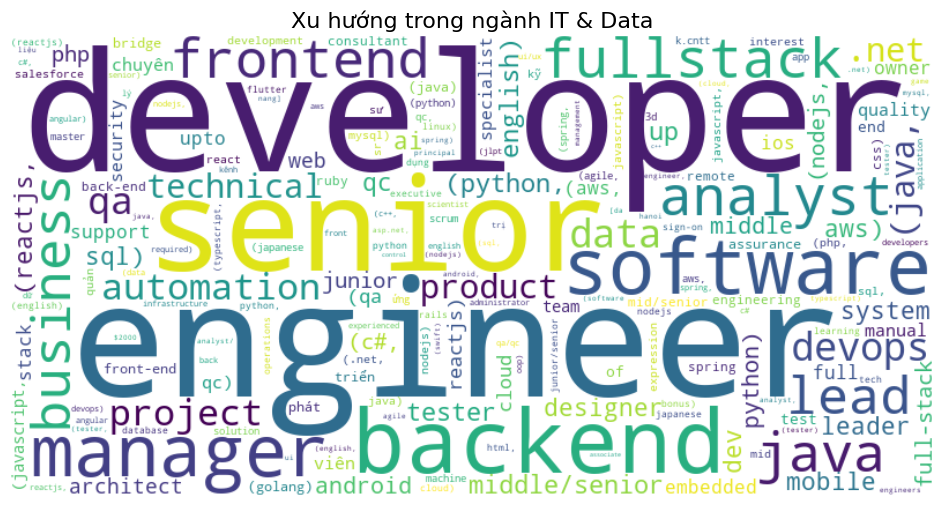

In [25]:
wc = WordCloud(width=800, height=400, background_color="white", font_path=None,
               stopwords=stopwords)
wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Xu hướng trong ngành IT & Data", fontsize=16)
plt.show()

**--- Đồ thị quan hệ giữa từ trong job title ---**

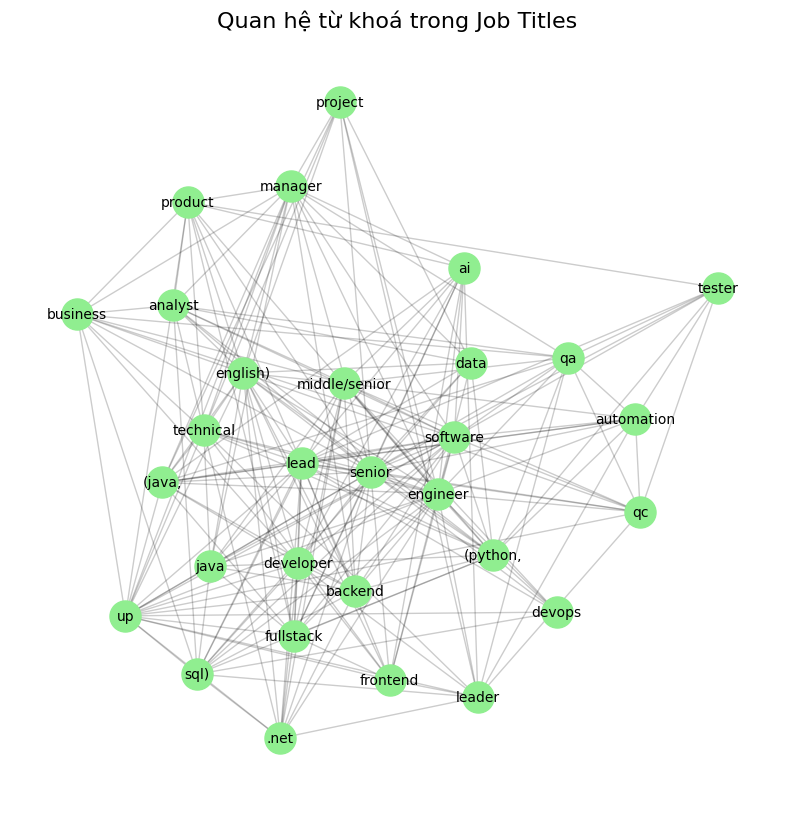

In [26]:
top_n = 30
common_words = [w for w, _ in word_counts.most_common(top_n)]

G = nx.Graph()
for title in jobs['job_title']:
    tokens = [t for t in title.lower().split() if t not in stopwords]
    tokens = [t for t in tokens if t in common_words]
    for i in range(len(tokens)):
        for j in range(i+1, len(tokens)):
            w1, w2 = tokens[i], tokens[j]
            if w1 != w2:
                if G.has_edge(w1, w2):
                    G[w1][w2]['weight'] += 1
                else:
                    G.add_edge(w1, w2, weight=1)

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx_edges(G, pos, alpha=0.2)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="lightgreen")
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Quan hệ từ khoá trong Job Titles", fontsize=16)
plt.axis("off")
plt.show()

**--- Biểu đồ top các ngành nghề được đề cập ---**

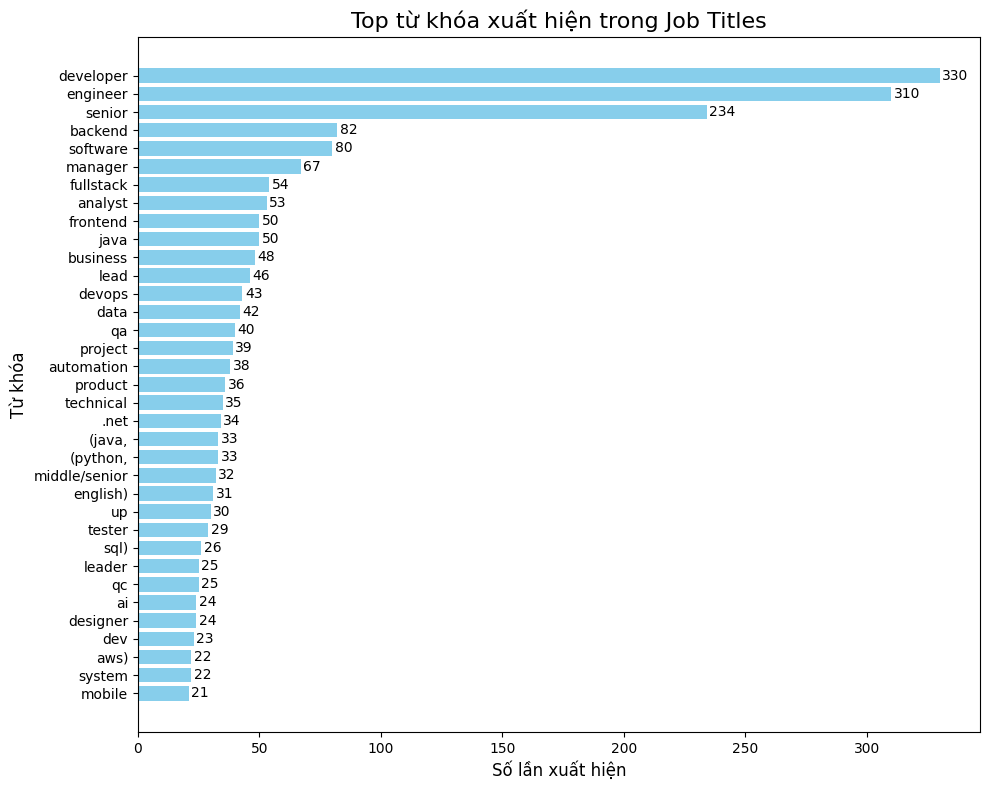

In [27]:
top_n = 35
common_words = word_counts.most_common(top_n)

words = [w for w, c in common_words]
counts = [c for w, c in common_words]

plt.figure(figsize=(10,8))
plt.barh(words[::-1], counts[::-1], color="skyblue")
plt.xlabel("Số lần xuất hiện", fontsize=12)
plt.ylabel("Từ khóa", fontsize=12)
plt.title("Top từ khóa xuất hiện trong Job Titles", fontsize=16)
for i, v in enumerate(counts[::-1]):
    plt.text(v + 1, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()